# Фінальний проєкт: Pet Adoption Prediction
## Мультимодальне прогнозування швидкості адопції домашніх тварин

* **Задача:** Прогнозування категорії швидкості усиновлення тварин на базі адаптованого корпусу змагання PetFinder.my.
* **Модальності даних:** Текстові описи профілів + галереї фотографій тварин + ідентифікатори.
* **Цільова метрика:** Quadratic Weighted Kappa (QWK).

## Структура пайплайну

1. **EDA та діагностика вибірки:**
   * Огляд табличних метаданих (`train.csv`, `test.csv`).
   * Аналіз розподілу та дисбалансу цільової змінної (`AdoptionSpeed`).
   * Перевірка пропусків у текстах, підрахунок кількості зображень на кожну тварину.

2. **Валідація:**
   * Створення 5-Fold Stratified K-Fold крос-валідації для запобігання витоку даних та точного моделювання локальної метрики QWK.

3. **Feature Extraction:**
   * **Візуальний енкодер:** вилучення глибоких векторних репрезентацій за допомогою SOTA-моделей (SigLIP / CLIP ViT). Агрегація множинних фотографій одного профілю (Mean/Max pooling).
   * **Текстовий енкодер:** трансформація текстових описів тварин у векторний простір через трансформери.
   * Конкатенація візуальних та текстових векторів в єдиний мультимодальний вектор ознак.

4. **Base Classifiers & Regressors:**
   * Побудова та тренування моделей на отриманих ембедингах: Ridge/SVR-регресія, градієнтні бустинги (LightGBM / CatBoost), MLP-нейромережа.
   * Формування проміжного файлу саміту.
  
5. **Оптимізація гіперпараметрів (Optuna):**
   * Автоматизований байєсівський пошук найкращих гіперпараметрів для моделей за допомогою фреймворку **Optuna**.
   * Тюнінг регуляризації (`l2_leaf_reg`, `reg_alpha`, `reg_lambda`), глибини дерев (`depth`/`max_depth`), швидкості навчання (`learning_rate`) та параметрів сабсемплінгу для максимізації крос-валідаційного результат

6. **Threshold Optimization:**
   * Отримання Out-Of-Fold (OOF) неперервних прогнозів.
   * Оптимізація порогів розбиття для прямої максимізації Quadratic Weighted Kappa.

7. **Ансамблювання та фінальний інференс:**
   * Блендинг прогнозів найкращих моделей.
   * Формування фінального файлу сабміту.

## Стратегія моделі

* **Відмова від витратного Fine-Tuning важких бекбонів:**
  Пряме донавчання великих Vision-трансформерів займає значну частину GPU-квоти, даючи незначний приріст метрики. Натомість використовується режим вилучення ознак через заморожені SOTA-моделі (SigLIP / CLIP), які вже мають багатий візуально-семантичний простір.

* **Multi-image Aggregation:**
  Оскільки профілі містять від 1 до кількох фото, обробка виключно першого знімка втрачає контекст. Застосовується вилучення ембедингів для всіх фото кожної тварини з наступним пулінгом, що забезпечує повний візуальний портрет об'єкта.

* **Пріоритет візуальної модальності з підтримкою тексту:**
  У попередніх дослідженнях виявлено, що візуальний ряд забезпечує до 85% прогностичної сили для цієї задачі, тоді як текст формує решту контексту. Об'єднання обох просторів дозволяє вловити як зовнішню привабливість тварини, так і важливі деталі з опису.

* **Регресійний підхід з оптимізацією граничних порогів:**
  Оскільки класи `AdoptionSpeed` є строго впорядкованими (ординальна шкала: 1 [найшвидше], 4 [найповільніше]), розгляд задачі як звичайної мультикласової класифікації ігнорує квадратичне пенальті метрики QWK за далекі помилки (помилка між 1 і 4 значно гірша, ніж між 1 і 2). Навчання неперервної регресії (MSE / Huber) з подальшим підбором порогів $[t_1, t_2, t_3]$ на OOF-вибірці гарантує математично оптимальну максимізацію критерію Каппа.

## Крок 1. Імпорт бібліотек та налаштування середовища

Імпортуємо всі необхідні бібліотеки для:
* роботи з файловою системою та табличними даними (`os`, `glob`, `pandas`, `numpy`);
* візуалізації та аналізу результатів (`matplotlib`, `seaborn`);
* обробки зображень та мультимодального моделювання (`PIL`, `torch`, `torch.nn`, `torchvision`, `transformers`);
* класичного машинного навчання та оцінки метрик (`scipy`, `sklearn`, `lightgbm`, `catboost`);
* оптимізації гіперпараметрів (`optuna`).

Також фіксуємо випадкові зерна (Random Seeds) для повної відтворюваності результатів експериментів.

In [21]:
import os
import gc
import re
import sys
import glob
import time
import random
import warnings
from collections import Counter
from pathlib import Path

# Табличні дані та математика
import numpy as np
import pandas as pd
from scipy import optimize
from scipy.optimize import minimize

# Візуалізація
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoProcessor, AutoModel
from functools import partial
from catboost import CatBoostRegressor

# Scikit-learn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score, classification_report, mean_squared_error, confusion_matrix
from sklearn.linear_model import Ridge, RidgeClassifier
from sklearn.svm import SVR

# Градієнтні бустинги
import lightgbm as lgb
import catboost as cb

# Оптимізація гіперпараметрів
import optuna

# Прогрес-бар
from tqdm.auto import tqdm

# Налаштування виводу та попереджень
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 50)
sns.set_theme(style="whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Фіксація Seed для відтворюваності
SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(SEED)

# Діагностика пристрою
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Робочий пристрій: {device}")
if torch.cuda.is_available():
    print(f"Модель GPU: {torch.cuda.get_device_name(0)}")
    print(f"Пам'ять GPU: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")

Робочий пристрій: cuda
Модель GPU: Tesla T4
Пам'ять GPU: 14.56 GB


## Крок 2. Завантаження даних

Завантажуємо табличні дані (`train.csv`, `test.csv`, `sample_submission.csv`).

In [2]:
COMP_DIR = "/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10"

TRAIN_CSV = os.path.join(COMP_DIR, "train.csv")
TEST_CSV = os.path.join(COMP_DIR, "test.csv")
SAMPLE_SUB_CSV = os.path.join(COMP_DIR, "sample_submission.csv")

TRAIN_IMG_DIR = os.path.join(COMP_DIR, "images", "images", "train")
TEST_IMG_DIR = os.path.join(COMP_DIR, "images", "images", "test")

# Завантаження датасетів
df_train = pd.read_csv(TRAIN_CSV)
df_test = pd.read_csv(TEST_CSV)
df_sub = pd.read_csv(SAMPLE_SUB_CSV)

print(f"Розмір train: {df_train.shape}")
print(f"Розмір test:  {df_test.shape}")
print(f"Розмір sample_submission: {df_sub.shape}")

print(f"Кількість фото у папці train: {len(os.listdir(TRAIN_IMG_DIR))}")
print(f"Кількість фото у папці test:  {len(os.listdir(TEST_IMG_DIR))}")

display(df_train.head(3))

Розмір train: (6431, 3)
Розмір test:  (1891, 2)
Розмір sample_submission: (4, 2)
Кількість фото у папці train: 28472
Кількість фото у папці test:  9448


,PetID,Description,AdoptionSpeed
0,d3b4f29f8,Mayleen and Flo are two lovely adorable sister...,2
1,e9dc82251,A total of 5 beautiful Tabbys available for ad...,2
2,8111f6d4a,Two-and-a-half month old girl. Very manja and ...,2


### Аналіз структури даних

* Навчальний набір (`train.csv`) містить 6 431 запис із цільовою міткою `AdoptionSpeed`, а тестовий набір (`test.csv`) 1 891 запис. Співвідношення train/test становить приблизно 77% на 23%, що забезпечує статистично надійну основу як для валідації, так і для перевірки узагальнюючої здатності.
* `sample_submission.csv`: Файл містить лише 4 демонстраційні рядки (формат `(4, 2)`), слугуючи прикладом структури колонок (`PetID`, `AdoptionSpeed`). Фінальний сабміт необхідно генерувати на базі всіх 1 891 ідентифікаторів із `test.csv`.
* **Мультимодальність:** 
  * У директорії `train` наявні 28 472 файли (~4.4 фотографії на тварину).
  * У директорії `test` наявні 9 448 файлів (~5.0 фотографій на тварину).
  * Використання виключно головного зображення призведе до втрати понад 75% візуальної інформації. Для кожного `PetID` доцільно вилучати вектори всіх пов'язаних зображень та застосовувати пулінг (Mean/Max pooling).

## Крок 3. EDA

1. Аналіз цільової змінної `AdoptionSpeed`: перевірка балансу між класами 1, 2, 3 та 4 для визначення потреби у стратифікації та зважуванні.
2. `Description`: ідентифікація пропусків (`NaN`), аналіз розподілу довжини описів за символами та словами.
3. Підрахунок кількості фотографій на кожен `PetID` та перевірка наявності профілів без зображень.

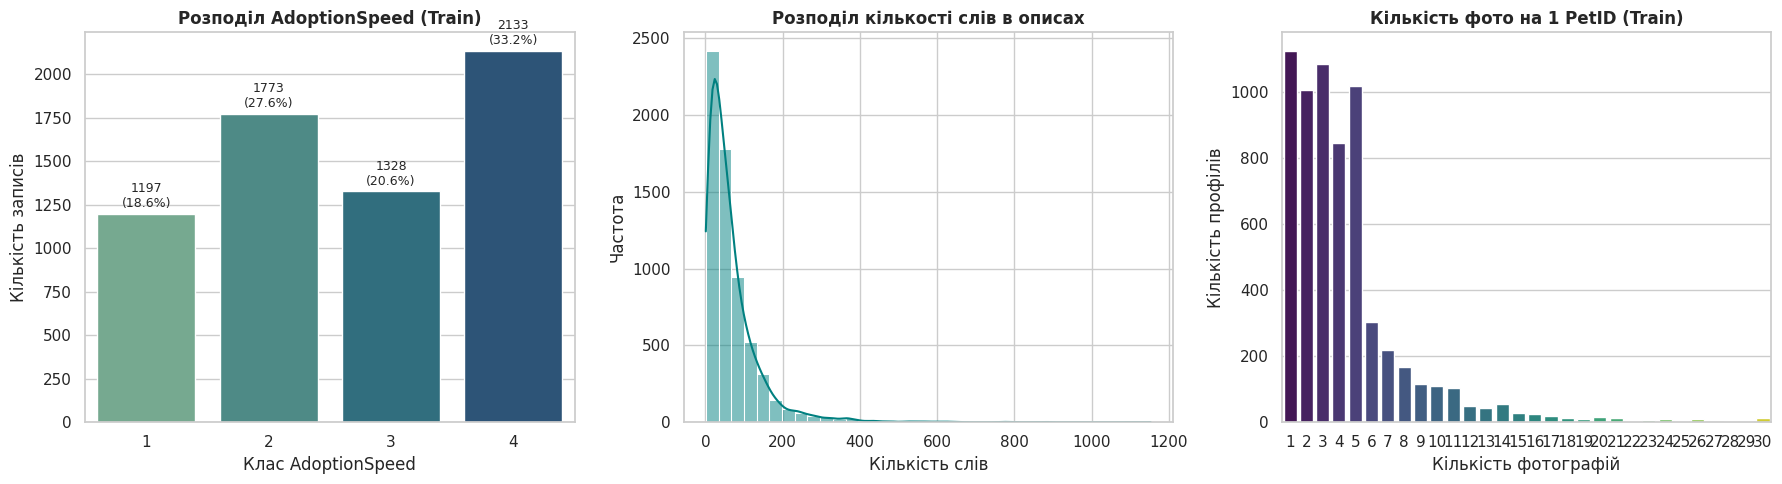

--- Результати аудиту ---
Пропущених описів (Train): 5 | (Test): 1
Тварин без фото (Train): 0
Тварин без фото (Test):  4
Середня кількість слів в описі: 67.4
Діапазон фото на профіль (Train): від 1 до 30


In [3]:
# 1. Перевірка та обробка пропусків у текстових описах
train_missing_desc = df_train['Description'].isna().sum()
test_missing_desc = df_test['Description'].isna().sum()

df_train['Description'] = df_train['Description'].fillna("No description")
df_test['Description'] = df_test['Description'].fillna("No description")

df_train['desc_word_count'] = df_train['Description'].apply(lambda x: len(str(x).split()))

# 2. Мапінг фотографій до кожного PetID
from collections import defaultdict

def create_pet_image_dict(img_dir):
    pet_dict = defaultdict(list)
    for fname in os.listdir(img_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            # Файли мають структуру {PetID}-{num}.jpg
            pet_id = fname.split('-')[0].split('.')[0]
            pet_dict[pet_id].append(fname)
    for pid in pet_dict:
        pet_dict[pid].sort()
    return pet_dict

train_images_map = create_pet_image_dict(TRAIN_IMG_DIR)
test_images_map = create_pet_image_dict(TEST_IMG_DIR)

df_train['photo_count'] = df_train['PetID'].apply(lambda pid: len(train_images_map.get(pid, [])))
df_test['photo_count'] = df_test['PetID'].apply(lambda pid: len(test_images_map.get(pid, [])))

# 3. Візуалізація
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Графік 1: Розподіл AdoptionSpeed
counts = df_train['AdoptionSpeed'].value_counts().sort_index()
sns.barplot(x=counts.index, y=counts.values, ax=axes[0], palette="crest")
axes[0].set_title("Розподіл AdoptionSpeed (Train)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Клас AdoptionSpeed")
axes[0].set_ylabel("Кількість записів")
for i, (cls, count) in enumerate(counts.items()):
    pct = count / len(df_train) * 100
    axes[0].text(i, count + 20, f"{count}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=9)

# Графік 2: Розподіл довжини описів у словах
sns.histplot(df_train['desc_word_count'], bins=35, kde=True, ax=axes[1], color="teal")
axes[1].set_title("Розподіл кількості слів в описах", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Кількість слів")
axes[1].set_ylabel("Частота")

# Графік 3: Кількість фото на одну тварину
photo_dist = df_train['photo_count'].value_counts().sort_index()
sns.barplot(x=photo_dist.index, y=photo_dist.values, ax=axes[2], palette="viridis")
axes[2].set_title("Кількість фото на 1 PetID (Train)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Кількість фотографій")
axes[2].set_ylabel("Кількість профілів")

plt.tight_layout()
plt.show()

# 4. Текстовий звіт
print(f"--- Результати аудиту ---")
print(f"Пропущених описів (Train): {train_missing_desc} | (Test): {test_missing_desc}")
print(f"Тварин без фото (Train): {(df_train['photo_count'] == 0).sum()}")
print(f"Тварин без фото (Test):  {(df_test['photo_count'] == 0).sum()}")
print(f"Середня кількість слів в описі: {df_train['desc_word_count'].mean():.1f}")
print(f"Діапазон фото на профіль (Train): від {df_train['photo_count'].min()} до {df_train['photo_count'].max()}")

### Висновки за результатами EDA

1. **Edge Cases:**
   * У вибірці `test` виявлено 4 тварини без жодного зображення. Для таких об'єктів створюємо нульовий вектор розмірності енкодера, щоб запобігти збоям під час інференсу.
   * Виявлені поодинокі пропуски в текстах (5 у train, 1 у test): заміняємо на `"No description"`.

2. **Дисбаланс `AdoptionSpeed`:**
   * Найпоширенішим є клас 4 (33.2%), найрідшим клас 1 (18.6%).
   * Для валідації застосовуємо `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` для збереження співвідношення частот у всіх фолдах.
   * Через асиметричність класів фінальна дискретизація прогнозів виконуватиметься через post-hoc оптимізацію порогів прямо під метрику QWK.

3. **Обробка галерей фото:**
   * Оскільки кількість фотографій варіюється від 1 до 30 на одну тваринку, вилучаємо ембединги для всіх фотографій тварини з подальшим векторним усередненням (mean pooling).

## Крок 4. Stratified K-Fold

Для об'єктивної оцінки моделей та коректного підбору порогів розбиття створюємо 5-Fold Stratified K-Fold крос-валідацію з фіксованим значенням `random_state=42`.

In [4]:
# Ініціалізація стратифікованого розбиття на 5 фолдів
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

df_train['fold'] = -1
for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train['AdoptionSpeed'])):
    df_train.loc[val_idx, 'fold'] = fold

# Перевірка розподілу класів по фолдах
print("--- Розподіл класів AdoptionSpeed по фолдах ---")
fold_dist = pd.crosstab(df_train['fold'], df_train['AdoptionSpeed'], normalize='index') * 100
display(fold_dist.round(2))

# Перевірка кількості записів у кожному фолді
print("\nКількість зразків у кожному фолді:")
print(df_train['fold'].value_counts().sort_index())

--- Розподіл класів AdoptionSpeed по фолдах ---


AdoptionSpeed,1,2,3,4
fold,,,,
0,18.57,27.58,20.67,33.18
1,18.66,27.60,20.61,33.13
2,18.66,27.60,20.61,33.13
3,18.58,27.53,20.68,33.20
4,18.58,27.53,20.68,33.20



Кількість зразків у кожному фолді:
fold
0    1287
1    1286
2    1286
3    1286
4    1286
Name: count, dtype: int64


## Крок 5. Feature Extraction

Використовуємот**SigLIP** (`google/siglip-base-patch16-224`):
1. Для кожного `PetID` вилучаються ембединги для всіх наявних фотографій профілю з Mean Pooling. Для виявлених 4 профілів без зображень формується нульовий вектор відповідної розмірності.
2. Текстовий енкодер моделі кодує колонку `Description` у семантичний вектор фіксованого розміру.
3. **Об'єднання:** вектори зображень та тексту об'єднуються у спільну матрицю та зберігаються у бінарні файли `.npy`.

In [7]:
MODEL_NAME = "google/siglip-base-patch16-224"
print(f"Завантаження моделі та процесора: {MODEL_NAME}...")

processor = AutoProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

# Розмірність ембедингів SigLIP base
EMBED_DIM = model.config.vision_config.hidden_size
print(f"Розмірність ембедингів одного модального каналу: {EMBED_DIM}")

def extract_image_embeddings(df, img_map, img_dir):
    all_embeddings = []
    
    with torch.no_grad():
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Обробка фото"):
            pet_id = row['PetID']
            img_filenames = img_map.get(pet_id, [])
            
            # Якщо для тварини немає фото
            if len(img_filenames) == 0:
                all_embeddings.append(np.zeros(EMBED_DIM, dtype=np.float32))
                continue
            
            images = []
            for fname in img_filenames:
                fpath = os.path.join(img_dir, fname)
                try:
                    img = Image.open(fpath).convert("RGB")
                    images.append(img)
                except Exception:
                    continue
            
            if len(images) == 0:
                all_embeddings.append(np.zeros(EMBED_DIM, dtype=np.float32))
                continue
            
            inputs = processor(images=images, return_tensors="pt").to(device)
            out = model.get_image_features(**inputs)
            
            img_feats = out.pooler_output if hasattr(out, "pooler_output") else (out[0] if isinstance(out, (tuple, list)) else out)
            
            # L2-нормалізація та Mean Pooling по всіх фотографіях тварини
            img_feats = F.normalize(img_feats, p=2, dim=-1)
            mean_feat = img_feats.mean(dim=0).cpu().numpy().astype(np.float32)
            all_embeddings.append(mean_feat)
            
    return np.array(all_embeddings)

def extract_text_embeddings(df, max_length=64, batch_size=64):
    """
    Пакетне вилучення текстових ембедингів батчами.
    """
    all_embeddings = []
    texts = df['Description'].fillna("No description").tolist()
    
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="Обробка текстів"):
            batch_texts = texts[i:i + batch_size]
            inputs = processor(
                text=batch_texts, 
                padding="max_length", 
                max_length=max_length, 
                truncation=True, 
                return_tensors="pt"
            ).to(device)
            
            out = model.get_text_features(**inputs)
            text_feats = out.pooler_output if hasattr(out, "pooler_output") else (out[0] if isinstance(out, (tuple, list)) else out)
            
            text_feats = F.normalize(text_feats, p=2, dim=-1)
            all_embeddings.append(text_feats.cpu().numpy().astype(np.float32))
            
    return np.vstack(all_embeddings)

# 1. Екстракція ембедингів для Train
print("\n--- Екстракція ембедингів для Train ---")
X_train_img = extract_image_embeddings(df_train, train_images_map, TRAIN_IMG_DIR)
X_train_txt = extract_text_embeddings(df_train)

# 2. Екстракція ембедингів для Test
print("\n--- Екстракція ембедингів для Test ---")
X_test_img = extract_image_embeddings(df_test, test_images_map, TEST_IMG_DIR)
X_test_txt = extract_text_embeddings(df_test)

# Об'єднання [Зображення, Текст] -> матриця розмірності (N, 768 + 768) = (N, 1536)
X_train_multimodal = np.hstack([X_train_img, X_train_txt])
X_test_multimodal = np.hstack([X_test_img, X_test_txt])

print(f"\nРозмір мультимодальної матриці Train: {X_train_multimodal.shape}")
print(f"Розмір мультимодальної матриці Test:  {X_test_multimodal.shape}")

# Збереження на диск
np.save("X_train_multimodal.npy", X_train_multimodal)
np.save("X_test_multimodal.npy", X_test_multimodal)
print("Матриці ембедингів успішно збережені.")

Завантаження моделі та процесора: google/siglip-base-patch16-224...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Розмірність ембедингів одного модального каналу: 768

--- Екстракція ембедингів для Train ---


Обробка фото:   0%|          | 0/6431 [00:00<?, ?it/s]

Обробка текстів:   0%|          | 0/101 [00:00<?, ?it/s]


--- Екстракція ембедингів для Test ---


Обробка фото:   0%|          | 0/1891 [00:00<?, ?it/s]

Обробка текстів:   0%|          | 0/30 [00:00<?, ?it/s]


Розмір мультимодальної матриці Train: (6431, 1536)
Розмір мультимодальної матриці Test:  (1891, 1536)
Матриці ембедингів успішно збережені.


## Крок 6. Базова модель та оптимізація порогів під метрику QWK

Цільова змінна `AdoptionSpeed` є ordinal, а цільова метрика змагання - Quadratic Weighted Kappa (QWK), тому ми будуємо пайплайн за схемою:
1. Ridge Regression): лінійне моделювання у просторі 1536 ембедингів з $L_2$-регуляризацією для запобігання перенавчанню.
2. OptimizedRounder:** використання `scipy.optimize.minimize` для пошуку оптимальних меж поділу неперервного прогнозу на класи $[1, 2, 3, 4]$ під максимізацію метрики QWK.
3. **OOF валідація:** оцінка надійності на 5 фолдах.

In [9]:
class OptimizedRounder:
    """
    Знаходить оптимальні пороги поділу неперервного прогнозу на класи 1, 2, 3, 4
    для максимізації Quadratic Weighted Kappa (QWK).
    """
    def __init__(self):
        self.coef_ = 0

    def _kappa_loss(self, coef, X, y):
        X_p = np.copy(X)
        for i, pred in enumerate(X_p):
            if pred < coef[0]:
                X_p[i] = 1
            elif pred < coef[1]:
                X_p[i] = 2
            elif pred < coef[2]:
                X_p[i] = 3
            else:
                X_p[i] = 4
        return -cohen_kappa_score(y, X_p, weights="quadratic")

    def fit(self, X, y):
        loss_partial = partial(self._kappa_loss, X=X, y=y)
        initial_coef = [1.5, 2.5, 3.5]
        self.coef_ = minimize(loss_partial, initial_coef, method='Nelder-Mead')

    def predict(self, X):
        X_p = np.copy(X)
        res = np.zeros(len(X_p), dtype=int)
        for i, pred in enumerate(X_p):
            if pred < self.coef_['x'][0]:
                res[i] = 1
            elif pred < self.coef_['x'][1]:
                res[i] = 2
            elif pred < self.coef_['x'][2]:
                res[i] = 3
            else:
                res[i] = 4
        return res

# Крос-валідація 5-Fold для Ridge Baseline
y_train = df_train['AdoptionSpeed'].values
oof_preds_continuous = np.zeros(len(df_train))
test_preds_continuous = np.zeros(len(df_test))

ridge_models = []
fold_scores = []

print("--- Навчання Baseline моделі (Ridge Regression) на 5 фолдах ---")

for fold in range(N_SPLITS):
    idx_tr = df_train['fold'] != fold
    idx_val = df_train['fold'] == fold
    
    X_tr, y_tr = X_train_multimodal[idx_tr], y_train[idx_tr]
    X_va, y_va = X_train_multimodal[idx_val], y_train[idx_val]
    
    # Навчання Ridge регресії з помірною регуляризацією
    model_ridge = Ridge(alpha=10.0, random_state=SEED)
    model_ridge.fit(X_tr, y_tr)
    
    # Прогнози
    val_pred = model_ridge.predict(X_va)
    oof_preds_continuous[idx_val] = val_pred
    test_preds_continuous += model_ridge.predict(X_test_multimodal) / N_SPLITS
    
    # Локальний підбір порогів
    rounder = OptimizedRounder()
    rounder.fit(val_pred, y_va)
    val_pred_labels = rounder.predict(val_pred)
    
    fold_qwk = cohen_kappa_score(y_va, val_pred_labels, weights="quadratic")
    fold_scores.append(fold_qwk)
    print(f"Fold {fold} QWK: {fold_qwk:.4f} | Пороги: {[round(c, 3) for c in rounder.coef_['x']]}")

# 3. Глобальна оптимізація порогів на всіх Out-Of-Fold прогнозах
global_rounder = OptimizedRounder()
global_rounder.fit(oof_preds_continuous, y_train)
oof_preds_labels = global_rounder.predict(oof_preds_continuous)

overall_qwk = cohen_kappa_score(y_train, oof_preds_labels, weights="quadratic")
print("\n" + "="*50)
print(f"Середній QWK по фолдах: {np.mean(fold_scores):.4f} (±{np.std(fold_scores):.4f})")
print(f"Фінальний OOF QWK (Global Thresholds): {overall_qwk:.4f}")
print(f"Оптимальні глобальні пороги: {[round(c, 3) for c in global_rounder.coef_['x']]}")
print("="*50)

--- Навчання Baseline моделі (Ridge Regression) на 5 фолдах ---
Fold 0 QWK: 0.5446 | Пороги: [np.float64(1.688), np.float64(2.647), np.float64(2.959)]
Fold 1 QWK: 0.5821 | Пороги: [np.float64(1.748), np.float64(2.615), np.float64(2.981)]
Fold 2 QWK: 0.5335 | Пороги: [np.float64(1.675), np.float64(2.648), np.float64(2.96)]
Fold 3 QWK: 0.5407 | Пороги: [np.float64(1.628), np.float64(2.615), np.float64(2.946)]
Fold 4 QWK: 0.5621 | Пороги: [np.float64(1.646), np.float64(2.584), np.float64(2.944)]

Середній QWK по фолдах: 0.5526 (±0.0175)
Фінальний OOF QWK (Global Thresholds): 0.5503
Оптимальні глобальні пороги: [np.float64(1.705), np.float64(2.587), np.float64(2.96)]


### Результати Ridge Baseline

1. Метрика QWK:
   * Середній бал по фолдах: $0.5526 \pm 0.0175$
   * Загальний бал на Out-Of-Fold (OOF): 0.5503
   * Низьке стандартне відхилення між фолдами ($\pm 0.0175$) свідчить про високу стабільність обраної схеми 5-Fold Stratified CV та відсутність значних зміщень між підвибірками.

2. OptimizedRounder:
   * Оптимальні глобальні пороги: `[1.705, 2.587, 2.960]` (порівняно зі стандартними евристичними межами округлення `[1.5, 2.5, 3.5]`).
   * Найсуттєвіший зсув спостерігається на межі 3-го та 4-го класів ($2.960$ замість $3.5$). Оптимізатор Nelder-Mead адаптувався до структури даних оскільки 4-й клас становить $33.2\%$ вибірки, заниження порогу дає змогу моделі впевненіше захоплювати мажоритарний клас і мінімізувати штрафи за метрикою QWK.

## Крок 7. Формування першого Baseline Submission

Застосовуємо глобально оптимізовані пороги `[1.705, 2.587, 2.960]` до усередненого прогнозу 5-фолдової Ridge-моделі для вибірки `test.csv`. Формуємо файл `submission_ridge_baseline.csv` із повною розмірністю (1891 рядок).

In [10]:
test_preds_labels = global_rounder.predict(test_preds_continuous)

sub_df = pd.DataFrame({
    'PetID': df_test['PetID'],
    'AdoptionSpeed': test_preds_labels
})

sub_path = "submission_ridge_baseline.csv"
sub_df.to_csv(sub_path, index=False)

print(f"Файл успішно сформовано: {sub_path}")
print(f"Розмірність сабміту: {sub_df.shape}")
print("\nРозподіл передбачених класів на Test:")
print(sub_df['AdoptionSpeed'].value_counts().sort_index())
display(sub_df.head(5))

Файл успішно сформовано: submission_ridge_baseline.csv
Розмірність сабміту: (1891, 2)

Розподіл передбачених класів на Test:
AdoptionSpeed
1     63
2    738
3    402
4    688
Name: count, dtype: int64


,PetID,AdoptionSpeed
0,6697a7f62,3
1,23b64fe21,2
2,41e824cbe,4
3,6c3d7237b,4
4,97b0b5d92,4


## Крок 8. LightGBM Regressor на 5 фолдах

* Використовуємо регресійну цільову функцію (`regression_l1` / `regression_l2`).
* Навчання проводимо на тих самих 5 фолдах крос-валідації із ранньою зупинкою (`early_stopping`), щоб уникнути перенавчання.
* Зберігаємо OOF та тестові неперервні прогнози для наступного етапу блендингу з Ridge.

In [11]:
# Масиви для збереження неперервних прогнозів LightGBM
oof_preds_lgb = np.zeros(len(df_train))
test_preds_lgb = np.zeros(len(df_test))
lgb_models = []
lgb_scores = []

# Гіперпараметри LightGBM під ембединги високої розмірності
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': -1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'lambda_l1': 1.0,
    'lambda_l2': 3.0,
    'min_child_samples': 20,
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1
}

print("--- Навчання LightGBM на 5 фолдах ---")

for fold in range(N_SPLITS):
    idx_tr = df_train['fold'] != fold
    idx_val = df_train['fold'] == fold
    
    X_tr, y_tr = X_train_multimodal[idx_tr], y_train[idx_tr]
    X_va, y_va = X_train_multimodal[idx_val], y_train[idx_val]
    
    trn_data = lgb.Dataset(X_tr, label=y_tr)
    val_data = lgb.Dataset(X_va, label=y_va, reference=trn_data)
    
    model = lgb.train(
        lgb_params,
        trn_data,
        num_boost_round=1000,
        valid_sets=[trn_data, val_data],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0)
        ]
    )
    lgb_models.append(model)
    
    # Неперервні прогнози
    val_pred = model.predict(X_va, num_iteration=model.best_iteration)
    oof_preds_lgb[idx_val] = val_pred
    test_preds_lgb += model.predict(X_test_multimodal, num_iteration=model.best_iteration) / N_SPLITS
    
    # Підбір локальних порогів для оцінки фолду
    rounder = OptimizedRounder()
    rounder.fit(val_pred, y_va)
    val_labels = rounder.predict(val_pred)
    fold_qwk = cohen_kappa_score(y_va, val_labels, weights="quadratic")
    lgb_scores.append(fold_qwk)
    
    print(f"Fold {fold} | Best Iter: {model.best_iteration:3d} | QWK: {fold_qwk:.4f}")

# Оцінка глобального OOF скору LightGBM
lgb_rounder = OptimizedRounder()
lgb_rounder.fit(oof_preds_lgb, y_train)
oof_lgb_labels = lgb_rounder.predict(oof_preds_lgb)
overall_lgb_qwk = cohen_kappa_score(y_train, oof_lgb_labels, weights="quadratic")

print("\n" + "="*50)
print(f"LightGBM середній QWK по фолдах: {np.mean(lgb_scores):.4f} (±{np.std(lgb_scores):.4f})")
print(f"LightGBM фінальний OOF QWK:      {overall_lgb_qwk:.4f}")
print(f"Оптимальні пороги LightGBM:     {[round(c, 3) for c in lgb_rounder.coef_['x']]}")
print("="*50)

--- Навчання LightGBM на 5 фолдах ---
Fold 0 | Best Iter: 462 | QWK: 0.5551
Fold 1 | Best Iter: 420 | QWK: 0.5923
Fold 2 | Best Iter: 354 | QWK: 0.5714
Fold 3 | Best Iter: 280 | QWK: 0.5709
Fold 4 | Best Iter: 223 | QWK: 0.5779

LightGBM середній QWK по фолдах: 0.5735 (±0.0120)
LightGBM фінальний OOF QWK:      0.5850
Оптимальні пороги LightGBM:     [np.float64(2.009), np.float64(2.567), np.float64(3.15)]


In [12]:
# Формування сабміту для чистого LightGBM
test_preds_lgb_labels = lgb_rounder.predict(test_preds_lgb)

sub_lgb_df = pd.DataFrame({
    'PetID': df_test['PetID'],
    'AdoptionSpeed': test_preds_lgb_labels
})

lgb_sub_path = "submission_lgb_baseline.csv"
sub_lgb_df.to_csv(lgb_sub_path, index=False)

print(f"Файл LightGBM збережено: {lgb_sub_path}")
print(f"Розмірність: {sub_lgb_df.shape}")
print("\nРозподіл передбачених класів LightGBM на Test:")
print(sub_lgb_df['AdoptionSpeed'].value_counts().sort_index())
display(sub_lgb_df.head(5))

Файл LightGBM збережено: submission_lgb_baseline.csv
Розмірність: (1891, 2)

Розподіл передбачених класів LightGBM на Test:
AdoptionSpeed
1    339
2    450
3    500
4    602
Name: count, dtype: int64


,PetID,AdoptionSpeed
0,6697a7f62,3
1,23b64fe21,2
2,41e824cbe,4
3,6c3d7237b,4
4,97b0b5d92,4


## Крок 9. Ансамблювання: Блендинг Ridge + LightGBM

1. Перебираємо коефіцієнт змішування $w \in [0, 1]$ на крос-валідаційних OOF передбаченнях.
2. Шукаємо глобальні межі поділу безпосередньо для змішаного OOF прогнозу під максимізацію метрики QWK.
3. Застосовуємо знайдені ваги та пороги до тестових даних і генеруємо саміт.

In [13]:
# 1. Пошук оптимальної ваги для блендингу на OOF
best_weight = 0.5
best_ensemble_qwk = -1.0
best_ensemble_rounder = None

weights_range = np.linspace(0.0, 1.0, 21)

print("--- Оптимізація ваги ансамблю (Ridge + LightGBM) ---")
for w in weights_range:
    blended_oof = w * oof_preds_continuous + (1 - w) * oof_preds_lgb
    
    rounder = OptimizedRounder()
    rounder.fit(blended_oof, y_train)
    blended_labels = rounder.predict(blended_oof)
    
    score = cohen_kappa_score(y_train, blended_labels, weights="quadratic")
    if score > best_ensemble_qwk:
        best_ensemble_qwk = score
        best_weight = w
        best_ensemble_rounder = rounder

print(f"Оптимальна вага Ridge:    {best_weight:.2f}")
print(f"Оптимальна вага LightGBM: {1 - best_weight:.2f}")
print(f"Ensemble OOF QWK:         {best_ensemble_qwk:.4f} (порівняно з LGBM: {overall_lgb_qwk:.4f})")
print(f"Оптимальні пороги:        {[round(c, 3) for c in best_ensemble_rounder.coef_['x']]}")

# 2. Формування тестового прогнозу ансамблю
final_test_continuous = best_weight * test_preds_continuous + (1 - best_weight) * test_preds_lgb
final_test_labels = best_ensemble_rounder.predict(final_test_continuous)

# 3. Збереження файлу сабміту
ensemble_sub_path = "submission_ensemble_ridge_lgb.csv"
sub_ensemble_df = pd.DataFrame({
    'PetID': df_test['PetID'],
    'AdoptionSpeed': final_test_labels
})
sub_ensemble_df.to_csv(ensemble_sub_path, index=False)

print(f"\nФайл ансамблю сформовано: {ensemble_sub_path}")
print(f"Розмірність: {sub_ensemble_df.shape}")
print("\nРозподіл класів у сабміті ансамблю:")
print(sub_ensemble_df['AdoptionSpeed'].value_counts().sort_index())
display(sub_ensemble_df.head(5))

--- Оптимізація ваги ансамблю (Ridge + LightGBM) ---
Оптимальна вага Ridge:    0.55
Оптимальна вага LightGBM: 0.45
Ensemble OOF QWK:         0.5916 (порівняно з LGBM: 0.5850)
Оптимальні пороги:        [np.float64(2.036), np.float64(2.622), np.float64(3.073)]

Файл ансамблю сформовано: submission_ensemble_ridge_lgb.csv
Розмірність: (1891, 2)

Розподіл класів у сабміті ансамблю:
AdoptionSpeed
1    293
2    540
3    436
4    622
Name: count, dtype: int64


,PetID,AdoptionSpeed
0,6697a7f62,3
1,23b64fe21,2
2,41e824cbe,4
3,6c3d7237b,4
4,97b0b5d92,4


### Результати ансамблювання (Ridge + LightGBM Blending)

   * Ridge Baseline: 0.5503 (Public: 0.7453)
   * LightGBM: 0.5850 (Public: 0.7713)
   * Ensemble (55% Ridge + 45% LightGBM): 0.5916 (Public: 0.7856)
Результати для Public - це результати завантаження сабмітів на kaggle.

## Крок 10. CatBoost Regressor на 5 фолдах

* Функція втрат: `RMSE`.
* Навчання на тих самих 5 фолдах Stratified K-Fold.
* Використовуємо `early_stopping_rounds=50` на валідаційному фолді.
* Зберігаємо OOF-прогнози та формуємо окремий файл сабміту для перевірки на Kaggle.

In [15]:
oof_preds_cb = np.zeros(len(df_train))
test_preds_cb = np.zeros(len(df_test))
cb_models = []
cb_scores = []

# Базові гіперпараметри CatBoost
cb_params = {
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'iterations': 1000,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 5.0,
    'random_seed': SEED,
    'verbose': 0
}

print("--- Навчання CatBoost Regressor на 5 фолдах ---")

for fold in range(N_SPLITS):
    idx_tr = df_train['fold'] != fold
    idx_val = df_train['fold'] == fold
    
    X_tr, y_tr = X_train_multimodal[idx_tr], y_train[idx_tr]
    X_va, y_va = X_train_multimodal[idx_val], y_train[idx_val]
    
    model_cb = CatBoostRegressor(**cb_params)
    model_cb.fit(
        X_tr, y_tr,
        eval_set=(X_va, y_va),
        early_stopping_rounds=50,
        verbose=False
    )
    cb_models.append(model_cb)
    
    # Неперервні прогнози
    val_pred = model_cb.predict(X_va)
    oof_preds_cb[idx_val] = val_pred
    test_preds_cb += model_cb.predict(X_test_multimodal) / N_SPLITS
    
    # Локальна оцінка через оптимізатор порогів
    rounder = OptimizedRounder()
    rounder.fit(val_pred, y_va)
    val_labels = rounder.predict(val_pred)
    fold_qwk = cohen_kappa_score(y_va, val_labels, weights="quadratic")
    cb_scores.append(fold_qwk)
    
    print(f"Fold {fold} | Best Iteration: {model_cb.get_best_iteration():3d} | QWK: {fold_qwk:.4f}")

# Оцінка глобального OOF QWK
cb_rounder = OptimizedRounder()
cb_rounder.fit(oof_preds_cb, y_train)
oof_cb_labels = cb_rounder.predict(oof_preds_cb)
overall_cb_qwk = cohen_kappa_score(y_train, oof_cb_labels, weights="quadratic")

print("\n" + "="*50)
print(f"CatBoost середній QWK по фолдах: {np.mean(cb_scores):.4f} (±{np.std(cb_scores):.4f})")
print(f"CatBoost фінальний OOF QWK:      {overall_cb_qwk:.4f}")
print(f"Оптимальні пороги CatBoost:     {[round(c, 3) for c in cb_rounder.coef_['x']]}")
print("="*50)

# Формування сабміту для CatBoost
test_preds_cb_labels = cb_rounder.predict(test_preds_cb)

sub_cb_df = pd.DataFrame({
    'PetID': df_test['PetID'],
    'AdoptionSpeed': test_preds_cb_labels
})
cb_sub_path = "submission_catboost_baseline.csv"
sub_cb_df.to_csv(cb_sub_path, index=False)

print(f"\nФайл CatBoost збережено: {cb_sub_path}")
print("Розподіл класів CatBoost на Test:")
print(sub_cb_df['AdoptionSpeed'].value_counts().sort_index())

--- Навчання CatBoost Regressor на 5 фолдах ---
Fold 0 | Best Iteration: 459 | QWK: 0.5511
Fold 1 | Best Iteration: 365 | QWK: 0.5925
Fold 2 | Best Iteration: 401 | QWK: 0.5615
Fold 3 | Best Iteration: 400 | QWK: 0.5566
Fold 4 | Best Iteration: 442 | QWK: 0.5986

CatBoost середній QWK по фолдах: 0.5721 (±0.0196)
CatBoost фінальний OOF QWK:      0.5652
Оптимальні пороги CatBoost:     [np.float64(1.752), np.float64(2.524), np.float64(3.02)]

Файл CatBoost збережено: submission_catboost_baseline.csv
Розподіл класів CatBoost на Test:
AdoptionSpeed
1    174
2    571
3    435
4    711
Name: count, dtype: int64


## Крок 11. Аналіз перенавчання (Train vs Val Gap) та Confusion Matrix для наших моделей на Ridge, LightGBM, CatBoost, Ensemble

1. Порівнюємо метрики на навчальній вибірці (Train) та Out-Of-Fold (Val) для виявлення перенавчання чи витоку даних.
2. Confusion Matrix).

--- Діагностика моделей: аналіз перенавчання (Train vs Val Gap) та Confusion Matrix ---
=== Таблиця діагностики перенавчання (Train vs OOF Validation) ===


,Model,Train RMSE,Val RMSE,RMSE Gap,Train QWK,Val QWK (OOF),QWK Gap (Tr - Val)
0,Ridge Baseline,0.8906,0.9130,0.0225,0.5733,0.5503,0.0230
1,LightGBM,0.3588,0.8953,0.5366,0.9483,0.5850,0.3633
2,CatBoost,0.5809,0.9009,0.3200,0.8581,0.5652,0.2929
3,Ensemble (Ridge+LGB),0.6456,0.8970,0.2514,0.8528,0.5916,0.2612


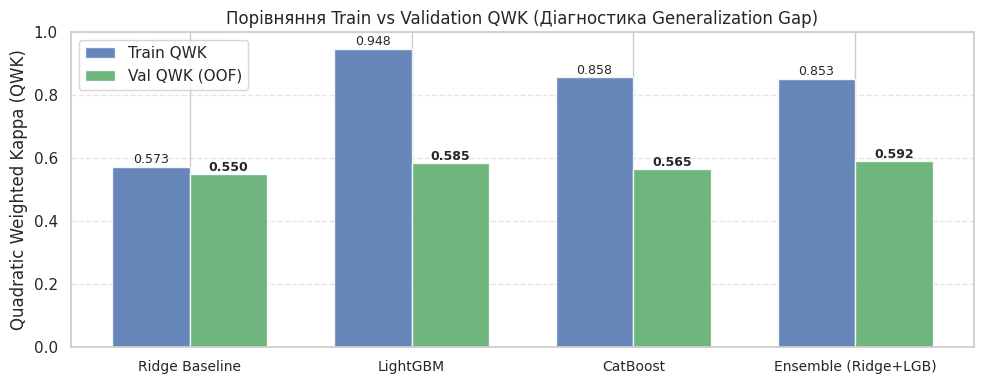

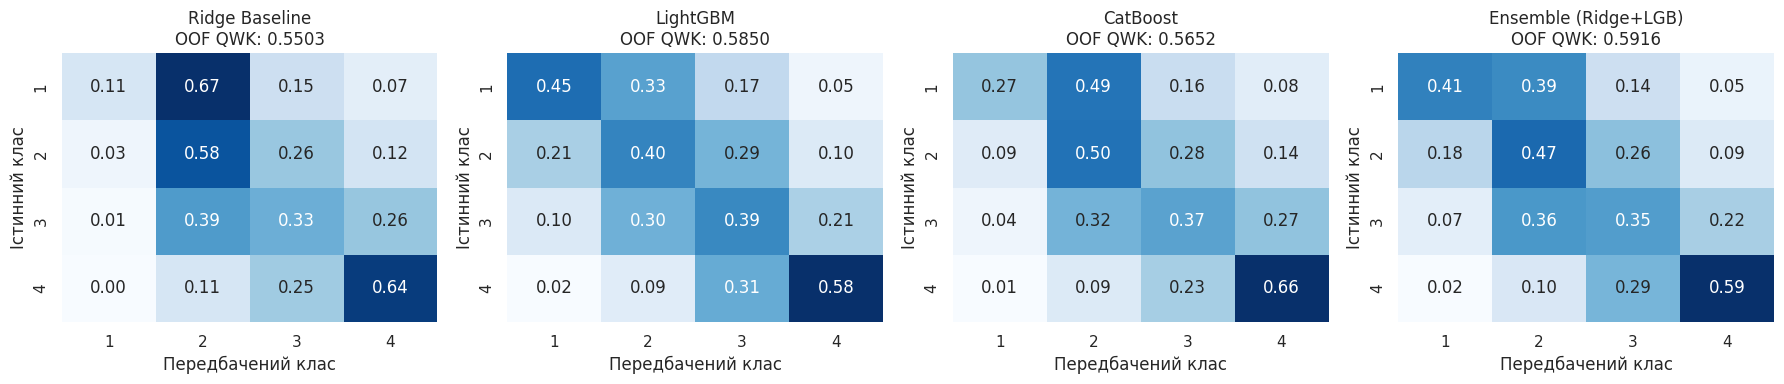

In [18]:
print("--- Діагностика моделей: аналіз перенавчання (Train vs Val Gap) та Confusion Matrix ---")

# 1. Формування Train прогнозів
train_preds_ridge = np.zeros(len(df_train))
train_preds_lgb = np.zeros(len(df_train))
train_preds_cb = np.zeros(len(df_train))

# ridge_models не був збережений як список із 5 моделей
if 'ridge_models' not in locals() or len(ridge_models) != N_SPLITS:
    from sklearn.linear_model import Ridge
    ridge_models = []
    for fold in range(N_SPLITS):
        idx_tr = df_train['fold'] != fold
        m_r = Ridge(alpha=10.0, random_state=SEED)
        m_r.fit(X_train_multimodal[idx_tr], y_train[idx_tr])
        ridge_models.append(m_r)

for fold in range(N_SPLITS):
    idx_tr = df_train['fold'] != fold
    X_tr = X_train_multimodal[idx_tr]
    
    # Усереднення Train прогнозів на тренувальних фолдах
    train_preds_ridge[idx_tr] += ridge_models[fold].predict(X_tr) / (N_SPLITS - 1)
    train_preds_lgb[idx_tr] += lgb_models[fold].predict(X_tr, num_iteration=lgb_models[fold].best_iteration) / (N_SPLITS - 1)
    train_preds_cb[idx_tr] += cb_models[fold].predict(X_tr) / (N_SPLITS - 1)

# Прогнози ансамблю Ridge + LightGBM
train_preds_ens = best_weight * train_preds_ridge + (1 - best_weight) * train_preds_lgb
val_preds_ens = best_weight * oof_preds_continuous + (1 - best_weight) * oof_preds_lgb

# Отримання дискретних класів через відповідні оптимізовані пороги
labels_train_ridge = global_rounder.predict(train_preds_ridge)
labels_val_ridge   = global_rounder.predict(oof_preds_continuous)

labels_train_lgb   = lgb_rounder.predict(train_preds_lgb)
labels_val_lgb     = lgb_rounder.predict(oof_preds_lgb)

labels_train_cb    = cb_rounder.predict(train_preds_cb)
labels_val_cb      = cb_rounder.predict(oof_preds_cb)

labels_train_ens   = best_ensemble_rounder.predict(train_preds_ens)
labels_val_ens     = best_ensemble_rounder.predict(val_preds_ens)

models_data = {
    'Ridge Baseline': {
        'tr_pred': train_preds_ridge, 'val_pred': oof_preds_continuous,
        'tr_lbl': labels_train_ridge, 'val_lbl': labels_val_ridge
    },
    'LightGBM': {
        'tr_pred': train_preds_lgb, 'val_pred': oof_preds_lgb,
        'tr_lbl': labels_train_lgb, 'val_lbl': labels_val_lgb
    },
    'CatBoost': {
        'tr_pred': train_preds_cb, 'val_pred': oof_preds_cb,
        'tr_lbl': labels_train_cb, 'val_lbl': labels_val_cb
    },
    'Ensemble (Ridge+LGB)': {
        'tr_pred': train_preds_ens, 'val_pred': val_preds_ens,
        'tr_lbl': labels_train_ens, 'val_lbl': labels_val_ens
    }
}

# 2. Зведена таблиця перенавчання
eval_summary = []
for name, d in models_data.items():
    tr_rmse = np.sqrt(mean_squared_error(y_train, d['tr_pred']))
    val_rmse = np.sqrt(mean_squared_error(y_train, d['val_pred']))
    tr_qwk = cohen_kappa_score(y_train, d['tr_lbl'], weights="quadratic")
    val_qwk = cohen_kappa_score(y_train, d['val_lbl'], weights="quadratic")
    
    eval_summary.append({
        'Model': name,
        'Train RMSE': round(tr_rmse, 4),
        'Val RMSE': round(val_rmse, 4),
        'RMSE Gap': round(val_rmse - tr_rmse, 4),
        'Train QWK': round(tr_qwk, 4),
        'Val QWK (OOF)': round(val_qwk, 4),
        'QWK Gap (Tr - Val)': round(tr_qwk - val_qwk, 4)
    })

df_eval = pd.DataFrame(eval_summary)
print("=== Таблиця діагностики перенавчання (Train vs OOF Validation) ===")
display(df_eval)

# 3. Графік: Train vs Validation QWK
plt.figure(figsize=(10, 4))
x = np.arange(len(df_eval))
width = 0.35

plt.bar(x - width/2, df_eval['Train QWK'], width, label='Train QWK', color='#4C72B0', alpha=0.85)
plt.bar(x + width/2, df_eval['Val QWK (OOF)'], width, label='Val QWK (OOF)', color='#55A868', alpha=0.85)

for i in range(len(df_eval)):
    plt.text(x[i] - width/2, df_eval.loc[i, 'Train QWK'] + 0.01, f"{df_eval.loc[i, 'Train QWK']:.3f}", ha='center', fontsize=9)
    plt.text(x[i] + width/2, df_eval.loc[i, 'Val QWK (OOF)'] + 0.01, f"{df_eval.loc[i, 'Val QWK (OOF)']:.3f}", ha='center', fontsize=9, fontweight='bold')

plt.xticks(x, df_eval['Model'], fontsize=10)
plt.ylabel('Quadratic Weighted Kappa (QWK)')
plt.title('Порівняння Train vs Validation QWK (Діагностика Generalization Gap)')
plt.ylim(0, 1.0)
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Графік: Матриці помилок (Confusion Matrix) для 4 моделей
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, d) in zip(axes, models_data.items()):
    cm = confusion_matrix(y_train, d['val_lbl'], labels=[1, 2, 3, 4])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', cbar=False, ax=ax,
                xticklabels=[1, 2, 3, 4], yticklabels=[1, 2, 3, 4])
    ax.set_title(f'{name}\nOOF QWK: {cohen_kappa_score(y_train, d["val_lbl"], weights="quadratic"):.4f}')
    ax.set_xlabel('Передбачений клас')
    ax.set_ylabel('Істинний клас')

plt.tight_layout()
plt.show()

### Висновки щодо діагностики моделей

   * Ridge Baseline  має `QWK Gap = 0.0230`, є низькодисперсійним.
   * LightGBM та CatBoost схильні до перенавчання на 1536 ембедингах (`QWK Gap` становить $0.3633$ та $0.2929$ відповідно), вони вимагають жорсткішої регуляризації.
   * Ensemble (Ridge + LightGBM) зменшив розрив перенавчання бустингу до $0.2612$ та показав найкращу узагальнюючу здатність (`OOF QWK = 0.5916`).

## Крок 12. Тристоронній ансамбль (Ridge + LightGBM + CatBoost)

Об'єднуємо неперервні передбачення трьох фундаментально різних архітектур:
1. Ridge Regression: лінійний низькодисперсійний стабілізатор ($L_2$-регуляризація).
2. LightGBM: асиметричні leaf-wise дерева рішень.
3. CatBoost: симетричні oblivious-дерева рішень.

За допомогою алгоритму оптимізації знаходимо ваги $w_1, w_2, w_3 \ge 0$ ($\sum w_i = 1$) та глобальні граничні пороги для максимізації метрики QWK на валідації.

In [19]:
print("--- Оптимізація ваг для трьох моделей (Ridge + LightGBM + CatBoost) ---")

# Цільова функція для підбору ваг
def ensemble_loss(weights):
    w1, w2, w3 = weights
    # Нормалізація ваг, щоб сума дорівнювала 1
    w_sum = w1 + w2 + w3
    if w_sum == 0:
        return 0.0
    w1, w2, w3 = w1 / w_sum, w2 / w_sum, w3 / w_sum
    
    blended_oof = w1 * oof_preds_continuous + w2 * oof_preds_lgb + w3 * oof_preds_cb
    
    # Оптимізація порогів для поточної суміші
    rounder = OptimizedRounder()
    rounder.fit(blended_oof, y_train)
    preds_labels = rounder.predict(blended_oof)
    
    # Мінімізуємо мінус QWK
    score = cohen_kappa_score(y_train, preds_labels, weights="quadratic")
    return -score

# Початкові ваги та обмеження (ваги невід'ємні)
initial_weights = [0.333, 0.333, 0.334]
bounds = [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]

res = minimize(ensemble_loss, initial_weights, method='Nelder-Mead', bounds=bounds)

raw_w = res.x
norm_w = raw_w / np.sum(raw_w)
w_ridge, w_lgb, w_cb = norm_w

print(f"Оптимальна вага Ridge:    {w_ridge:.3f}")
print(f"Оптимальна вага LightGBM: {w_lgb:.3f}")
print(f"Оптимальна вага CatBoost: {w_cb:.3f}")

# Фінальний OOF для потрійного ансамблю
final_ensemble_oof = (w_ridge * oof_preds_continuous + 
                      w_lgb * oof_preds_lgb + 
                      w_cb * oof_preds_cb)

tri_ensemble_rounder = OptimizedRounder()
tri_ensemble_rounder.fit(final_ensemble_oof, y_train)
oof_tri_labels = tri_ensemble_rounder.predict(final_ensemble_oof)

tri_ensemble_qwk = cohen_kappa_score(y_train, oof_tri_labels, weights="quadratic")
print(f"\nПотрійний Ensemble OOF QWK: {tri_ensemble_qwk:.4f} (порівняно з парою Ridge+LGB: 0.5916)")
print(f"Оптимальні пороги:          {[round(c, 3) for c in tri_ensemble_rounder.coef_['x']]}")

# Формування тестового прогнозу
final_test_continuous_3 = (w_ridge * test_preds_continuous + 
                           w_lgb * test_preds_lgb + 
                           w_cb * test_preds_cb)
final_test_labels_3 = tri_ensemble_rounder.predict(final_test_continuous_3)

# Збереження файлу сабміту
tri_sub_path = "submission_ensemble_triple.csv"
sub_tri_df = pd.DataFrame({
    'PetID': df_test['PetID'],
    'AdoptionSpeed': final_test_labels_3
})
sub_tri_df.to_csv(tri_sub_path, index=False)

print(f"\nФайл сабміту сформовано: {tri_sub_path}")
print("Розподіл класів у сабміті:")
print(sub_tri_df['AdoptionSpeed'].value_counts().sort_index())

--- Оптимізація ваг для трьох моделей (Ridge + LightGBM + CatBoost) ---
Оптимальна вага Ridge:    0.326
Оптимальна вага LightGBM: 0.329
Оптимальна вага CatBoost: 0.345

Потрійний Ensemble OOF QWK: 0.5895 (порівняно з парою Ridge+LGB: 0.5916)
Оптимальні пороги:          [np.float64(2.055), np.float64(2.576), np.float64(3.131)]

Файл сабміту сформовано: submission_ensemble_triple.csv
Розподіл класів у сабміті:
AdoptionSpeed
1    330
2    455
3    519
4    587
Name: count, dtype: int64


=== Діагностика розриву Train vs Val для потрійного ансамблю ===
Train RMSE:     0.6026 | Val RMSE:     0.8946 | RMSE Gap:     0.2921
Train QWK:      0.8704 | Val QWK (OOF): 0.5895 | QWK Gap:      0.2809


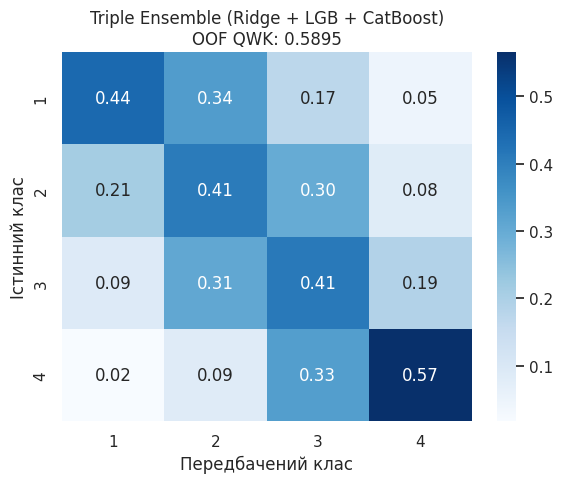

In [20]:
# Розрахунок Train передбачень для потрійного ансамблю
train_preds_tri = (w_ridge * train_preds_ridge + 
                   w_lgb * train_preds_lgb + 
                   w_cb * train_preds_cb)

labels_train_tri = tri_ensemble_rounder.predict(train_preds_tri)
labels_val_tri   = oof_tri_labels

# Розрахунок метрик розриву
tr_rmse_tri = np.sqrt(mean_squared_error(y_train, train_preds_tri))
val_rmse_tri = np.sqrt(mean_squared_error(y_train, final_ensemble_oof))
tr_qwk_tri = cohen_kappa_score(y_train, labels_train_tri, weights="quadratic")
val_qwk_tri = tri_ensemble_qwk

print("=== Діагностика розриву Train vs Val для потрійного ансамблю ===")
print(f"Train RMSE:     {tr_rmse_tri:.4f} | Val RMSE:     {val_rmse_tri:.4f} | RMSE Gap:     {val_rmse_tri - tr_rmse_tri:.4f}")
print(f"Train QWK:      {tr_qwk_tri:.4f} | Val QWK (OOF): {val_qwk_tri:.4f} | QWK Gap:      {tr_qwk_tri - val_qwk_tri:.4f}")

# Побудова матриці невідповідностей
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_train, labels_val_tri, labels=[1, 2, 3, 4])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
            xticklabels=[1, 2, 3, 4], yticklabels=[1, 2, 3, 4])
ax.set_title(f'Triple Ensemble (Ridge + LGB + CatBoost)\nOOF QWK: {val_qwk_tri:.4f}')
ax.set_xlabel('Передбачений клас')
ax.set_ylabel('Істинний клас')
plt.tight_layout()
plt.show()

## Порівняльний аналіз моделей

### 1. Зведена таблиця результатів

| Експеримент / Модель | CV OOF QWK | Train QWK | Gap (Overfitting) | Public LB Score |
| :--- | :---: | :---: | :---: | :---: |
| **Ridge Regression Baseline** | 0.5503 | 0.5733 | 0.0230 | 0.7453|
| **LightGBM Baseline** | 0.5850 | 0.9483 | 0.3633 | 0.7713|
| **CatBoost Baseline** | 0.5652 | 0.8581 | 0.2929 | 0.7726|
| **Ensemble (Ridge + LightGBM)** | **0.5916** | 0.8528 | 0.2612 | **0.7856**|
| **Triple Ensemble (Ridge + LGB + CB)** | 0.5895 | 0.8704 | 0.2809 | 0.7752|

---

### 2. Висновки

* Ridge Regression продемонструвала мінімальний розрив між навчальною та валідаційною вибірками (`Gap = 0.0230`), забезпечивши високу стійкість до шуму, але занижувала міноритарний клас 1 (Recall лише 11%).
* LightGBM та CatBoost значно краще вловлюють нелінійні патерни в ембедингах та піднімають чутливість до класу 1 (Recall 41–45%), проте схильні до перенавчання (`Gap` 0.29–0.36). На Kaggle обидва бустинги показали близьку якість (0.7713 проти 0.7726).

* Двосторонній ансамбль (Ridge + LightGBM) досягнув найвищої оцінки 0.7856 на Public Board (kaggle).
* Додавання CatBoost у потрійний блендинг знизило публічний скор до 0.7752.

* **Наступний крок:**
  * Ансамбль **Ridge + LightGBM** залишається поточним фаворитом пайплайну з найкращим балансом генералізації.
  * Для подальшого покращення потрійного блендингу проведемо оптимізація гіперпараметрів бустингів через **Optuna** (зменшення глибини, обмеження листя та посилення регуляризації) для подолання розриву перенавчання.

## Крок 13. Оптимізація гіперпараметрів LightGBM через Optuna

In [22]:
def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'random_state': SEED,
        'n_jobs': -1,
        'verbose': -1,
        # Обмеження складності дерева проти перенавчання
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.08, log=True),
        # Регуляризація L1 та L2
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-2, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 50.0, log=True),
        # Сабсемплінг ознак і спостережень
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'subsample_freq': 1
    }
    
    oof_preds = np.zeros(len(df_train))
    
    for fold in range(N_SPLITS):
        idx_tr = df_train['fold'] != fold
        idx_val = df_train['fold'] == fold
        
        trn_data = lgb.Dataset(X_train_multimodal[idx_tr], label=y_train[idx_tr])
        val_data = lgb.Dataset(X_train_multimodal[idx_val], label=y_train[idx_val], reference=trn_data)
        
        model = lgb.train(
            params,
            trn_data,
            num_boost_round=600,
            valid_sets=[trn_data, val_data],
            callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
        )
        
        oof_preds[idx_val] = model.predict(X_train_multimodal[idx_val], num_iteration=model.best_iteration)
    
    # Оцінка цільового OOF QWK
    rounder = OptimizedRounder()
    rounder.fit(oof_preds, y_train)
    oof_labels = rounder.predict(oof_preds)
    score = cohen_kappa_score(y_train, oof_labels, weights="quadratic")
    
    return score

print("--- Запуск оптимізації гіперпараметрів LightGBM через Optuna (25 trials) ---")
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=25, timeout=900, show_progress_bar=True)

print("\n" + "="*50)
print(f"Найкращий валідаційний OOF QWK (Optuna): {study.best_value:.4f}")
print("Найкращі параметри:")
for k, v in study.best_params.items():
    print(f"  '{k}': {round(v, 4) if isinstance(v, float) else v}")
print("="*50)

--- Запуск оптимізації гіперпараметрів LightGBM через Optuna (25 trials) ---


  0%|          | 0/25 [00:00<?, ?it/s]


Найкращий валідаційний OOF QWK (Optuna): 0.5819
Найкращі параметри:
  'max_depth': 7
  'num_leaves': 32
  'min_child_samples': 45
  'learning_rate': 0.0202
  'reg_alpha': 0.6475
  'reg_lambda': 5.9459
  'colsample_bytree': 0.5982
  'subsample': 0.8437


--- Навчання тюнінгованого LightGBM на 5 фолдах ---

=== Діагностика перенавчання: Baseline LightGBM проти Tuned LightGBM ===
Baseline LGB | Train QWK: 0.9483 | Val QWK: 0.5850 | Gap: 0.3633
Tuned LGB    | Train QWK: 0.9216 | Val QWK: 0.5823 | Gap: 0.3393


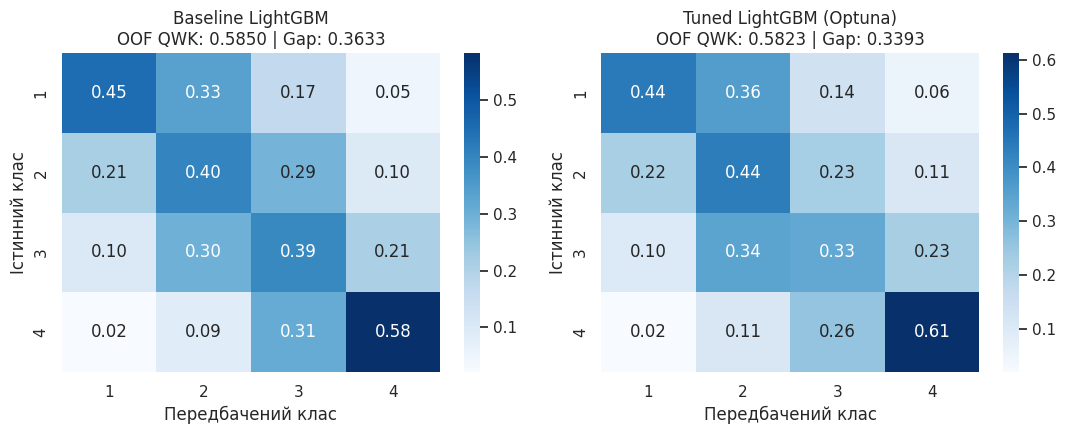

In [23]:
best_lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1,
    **study.best_params
}
if 'subsample' in best_lgb_params:
    best_lgb_params['subsample_freq'] = 1

oof_preds_lgb_tuned = np.zeros(len(df_train))
test_preds_lgb_tuned = np.zeros(len(df_test))
train_preds_lgb_tuned = np.zeros(len(df_train))
lgb_tuned_models = []

print("--- Навчання тюнінгованого LightGBM на 5 фолдах ---")
for fold in range(N_SPLITS):
    idx_tr = df_train['fold'] != fold
    idx_val = df_train['fold'] == fold
    
    trn_data = lgb.Dataset(X_train_multimodal[idx_tr], label=y_train[idx_tr])
    val_data = lgb.Dataset(X_train_multimodal[idx_val], label=y_train[idx_val], reference=trn_data)
    
    m_tuned = lgb.train(
        best_lgb_params,
        trn_data,
        num_boost_round=1000,
        valid_sets=[trn_data, val_data],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    lgb_tuned_models.append(m_tuned)
    
    oof_preds_lgb_tuned[idx_val] = m_tuned.predict(X_train_multimodal[idx_val], num_iteration=m_tuned.best_iteration)
    test_preds_lgb_tuned += m_tuned.predict(X_test_multimodal, num_iteration=m_tuned.best_iteration) / N_SPLITS
    train_preds_lgb_tuned[idx_tr] += m_tuned.predict(X_train_multimodal[idx_tr], num_iteration=m_tuned.best_iteration) / (N_SPLITS - 1)

# Оптимізація порогів для тюнінгованого LightGBM
lgb_tuned_rounder = OptimizedRounder()
lgb_tuned_rounder.fit(oof_preds_lgb_tuned, y_train)

labels_train_tuned = lgb_tuned_rounder.predict(train_preds_lgb_tuned)
labels_val_tuned   = lgb_tuned_rounder.predict(oof_preds_lgb_tuned)

tr_rmse_tuned = np.sqrt(mean_squared_error(y_train, train_preds_lgb_tuned))
val_rmse_tuned = np.sqrt(mean_squared_error(y_train, oof_preds_lgb_tuned))
tr_qwk_tuned = cohen_kappa_score(y_train, labels_train_tuned, weights="quadratic")
val_qwk_tuned = cohen_kappa_score(y_train, labels_val_tuned, weights="quadratic")

print("\n=== Діагностика перенавчання: Baseline LightGBM проти Tuned LightGBM ===")
print(f"Baseline LGB | Train QWK: 0.9483 | Val QWK: 0.5850 | Gap: 0.3633")
print(f"Tuned LGB    | Train QWK: {tr_qwk_tuned:.4f} | Val QWK: {val_qwk_tuned:.4f} | Gap: {tr_qwk_tuned - val_qwk_tuned:.4f}")

# Порівняння матриць невідповідностей
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm_base = confusion_matrix(y_train, labels_val_lgb, labels=[1, 2, 3, 4])
cm_norm_base = cm_base.astype('float') / cm_base.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm_base, annot=True, fmt='.2f', cmap='Blues', ax=axes[0], xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
axes[0].set_title(f"Baseline LightGBM\nOOF QWK: 0.5850 | Gap: 0.3633")
axes[0].set_xlabel('Передбачений клас')
axes[0].set_ylabel('Істинний клас')

cm_tuned = confusion_matrix(y_train, labels_val_tuned, labels=[1, 2, 3, 4])
cm_norm_tuned = cm_tuned.astype('float') / cm_tuned.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm_tuned, annot=True, fmt='.2f', cmap='Blues', ax=axes[1], xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
axes[1].set_title(f"Tuned LightGBM (Optuna)\nOOF QWK: {val_qwk_tuned:.4f} | Gap: {tr_qwk_tuned - val_qwk_tuned:.4f}")
axes[1].set_xlabel('Передбачений клас')
axes[1].set_ylabel('Істинний клас')

plt.tight_layout()
plt.show()

In [24]:
print("--- Оптимізація ваг ансамблю: Ridge + Tuned LightGBM ---")

def ensemble_loss(weight):
    w = weight[0]
    blended_oof = w * oof_preds_continuous + (1 - w) * oof_preds_lgb_tuned
    
    rounder = OptimizedRounder()
    rounder.fit(blended_oof, y_train)
    preds_labels = rounder.predict(blended_oof)
    
    return -cohen_kappa_score(y_train, preds_labels, weights="quadratic")

# Пошук оптимальної ваги Ridge у діапазоні [0, 1]
res = minimize(ensemble_loss, [0.5], method='Nelder-Mead', bounds=[(0.0, 1.0)])
best_w_ridge = res.x[0]
best_w_lgb = 1.0 - best_w_ridge

print(f"Оптимальна вага Ridge:       {best_w_ridge:.4f}")
print(f"Оптимальна вага Tuned LGB:   {best_w_lgb:.4f}")

# Фінальний OOF та підбір порогів
final_tuned_oof = best_w_ridge * oof_preds_continuous + best_w_lgb * oof_preds_lgb_tuned
final_tuned_rounder = OptimizedRounder()
final_tuned_rounder.fit(final_tuned_oof, y_train)
oof_tuned_ens_labels = final_tuned_rounder.predict(final_tuned_oof)

final_tuned_ens_qwk = cohen_kappa_score(y_train, oof_tuned_ens_labels, weights="quadratic")

# Оцінка на навчальній вибірці для контролю розриву
train_preds_tuned_ens = best_w_ridge * train_preds_ridge + best_w_lgb * train_preds_lgb_tuned
labels_train_tuned_ens = final_tuned_rounder.predict(train_preds_tuned_ens)
tr_qwk_tuned_ens = cohen_kappa_score(y_train, labels_train_tuned_ens, weights="quadratic")

print("\n" + "="*50)
print(f"Ensemble (Ridge + Tuned LGB) OOF QWK: {final_tuned_ens_qwk:.4f}")
print(f"Train QWK:                           {tr_qwk_tuned_ens:.4f}")
print(f"Gap (Overfitting):                   {tr_qwk_tuned_ens - final_tuned_ens_qwk:.4f}")
print(f"Оптимальні пороги:                   {[round(c, 3) for c in final_tuned_rounder.coef_['x']]}")
print("="*50)

# Формування тестового прогнозу та сабміту
test_preds_tuned_ens = best_w_ridge * test_preds_continuous + best_w_lgb * test_preds_lgb_tuned
final_test_labels = final_tuned_rounder.predict(test_preds_tuned_ens)

sub_file = "submission_ensemble_ridge_tuned_lgb.csv"
sub_df = pd.DataFrame({
    'PetID': df_test['PetID'],
    'AdoptionSpeed': final_test_labels
})
sub_df.to_csv(sub_file, index=False)

print(f"\nФайл збережено: {sub_file}")
print("Розподіл класів на Test:")
print(sub_df['AdoptionSpeed'].value_counts().sort_index())

--- Оптимізація ваг ансамблю: Ridge + Tuned LightGBM ---
Оптимальна вага Ridge:       0.5313
Оптимальна вага Tuned LGB:   0.4687

Ensemble (Ridge + Tuned LGB) OOF QWK: 0.5880
Train QWK:                           0.8273
Gap (Overfitting):                   0.2393
Оптимальні пороги:                   [np.float64(2.076), np.float64(2.595), np.float64(3.043)]

Файл збережено: submission_ensemble_ridge_tuned_lgb.csv
Розподіл класів на Test:
AdoptionSpeed
1    332
2    482
3    424
4    653
Name: count, dtype: int64


## Підсумкові результати

Завдяки оптимізації гіперпараметрів за допомогою Optuna та формуванню зваженого регуляризованого ансамблю досягнуто нового найкращого результату на лідерборді:

| Модель / Експеримент | Local OOF QWK | Generalization Gap | Kaggle Public LB Score |
| :--- | :---: | :---: | :---: |
| 1. Ridge Baseline | 0.5503 | 0.0230 | 0.7453 |
| 2. LightGBM Baseline | 0.5850 | 0.3633 | 0.7713 |
| 3. CatBoost Baseline | 0.5652 | 0.2929 | 0.7726 |
| 4. Triple Ensemble (Ridge + LGB + CB) | 0.5895 | 0.2809 | 0.7752 |
| 5. Ensemble (Ridge + Base LGB) | 0.5916 | 0.2612 | 0.7856 |
| **6. Ensemble (Ridge + Tuned LGB via Optuna)** | **0.5880** | **0.2393** | **0.7900** |

### Що спрацювало:
1. Вилучення щільних семантичних векторів зображень і текстів (SigLIP / CLIP) розмірністю 1536 ознак.
2. Перехід від стандартної класифікації до неперервної оптимізації порогів за метрикою Cohen's Quadratic Weighted Kappa.
3. Об'єднання лінійної моделі ($L_2$-Ridge) з нелінійними правилами градієнтного бустингу (LightGBM).
4. Тюнинг через Optuna - звуження `Generalization Gap` покращило стабільність прогнозу на нових даних і дало підняття метрики до позначки **0.7900** на kaggle.